# SEIRT model

In [15]:
import matplotlib
matplotlib.__version__

'3.10.3'

omega = 0


C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3404: RuntimeWarning: divide by zero encountered in divide
  Kfactor = np.where(Kvec==0, 0, (Kvec - 1) / Kvec ) # (k-1)/k for each k in K, except k=0 where it is 0.
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3408: RuntimeWarning: invalid value encountered in divide
  term_ix = np.where(Qik[:,None] == 0, 0, bijz * Kfactor[:,None] * (QzQik[:,None] * QikQxl) / Qik[:,None]) #0 where den=0, otherwise using ratio
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3412: RuntimeWarning: invalid value encountered in divide
  term_xi = np.where(Qik == 0, 0, bijz * Kfactor*(QxlQik*QikQz)/ Qik) #0 where den=0, otherwise using ratio


return_full_data should return edge counts as well
omega = 1
return_full_data should return edge counts as well
omega = 2
return_full_data should return edge counts as well
omega = 3
return_full_data should return edge counts as well


C:\Users\JCMiller\AppData\Local\Temp\ipykernel_34836\1023404279.py:110: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('Cont_Tracing_proof_of_concept.png', dpi=900)


xi = 0.35
gamma = 1
tau = 1.5
sigma = 0.7
zeta = 1


c:\Users\JCMiller\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


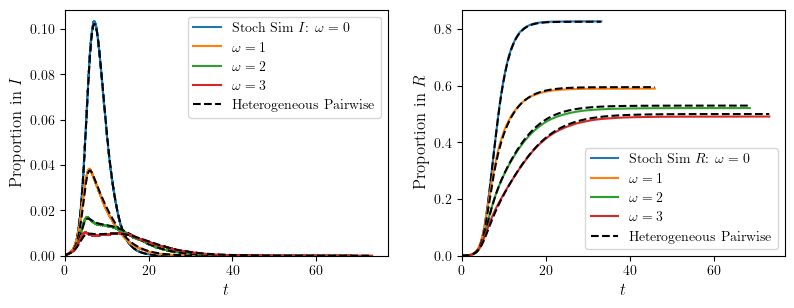

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict
import itertools
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

rng = np.random.default_rng(seed = 1)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

#omega = 0.035
sigma = 0.7
gamma = 1
tau = 1.5
zeta = gamma
xi = 0.35

N=500000
initial_E_count = 1000


deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)
G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3))
fig.subplots_adjust(left=0.09, right=0.99, wspace=0.23, bottom=0.16, top=0.98 )# Increase right, decrease wspace for wider axes


IC = defaultdict(lambda: 'S')
for node in range(initial_E_count):
    IC[node] = 'E'

return_statuses = ['S', 'E', 'I', 'R', 'T']
color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

for counter, omega in enumerate([0, 1, 2, 3]):#0.2, 0.4, 0.8, 1.6, 3.2]):
    print("omega = {}".format(omega))
    H_seirt = nx.DiGraph()
    H_seirt.add_weighted_edges_from([('E', 'I', sigma), ('I', 'R', gamma), ('I', 'T', xi), ('T', 'R', zeta)], weight='rate')

    # J_seirt = nx.DiGraph()
    # J_seirt.add_weighted_edges_from([(('I', 'S'), ('I', 'E'), tau), (('T', 'I'), ('T', 'T'), omega), (('T', 'E'), ('T', 'T'), omega)], weight = 'rate')
    J_seirt = nx.DiGraph()
    J_seirt.add_weighted_edges_from([(('I', 'S'), ('I', 'E'), tau), #(('E', 'S'), ('E', 'E'), tau), 
                                     (('T', 'I'), ('T', 'T'), omega), (('T', 'E'), ('T', 'T'), omega)], weight = 'rate')


    t, S, E, I, R, T = EoN.fast_simple_contagion(G, H_seirt, J_seirt, IC, return_statuses=return_statuses)  
    tt, SS, EE, II, RR, TT = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_seirt, J_seirt, IC, return_statuses, return_statuses=return_statuses, tmax = t[-1])



    #colorx = next(color_cycle)
    colory = next(color_cycle)
#plt.plot(t, S, label = 'S')
    #plt.plot(t, E/N, '--', label = 'Stoch Sim: $E$, $\\xi = ${}'.format(xi), color = colorx)
#plt.plot(t, R, label = 'R')


    #plt.plot(tt, EE/N, ':', label = 'Het Pw: $E$', color = colorx)

    if counter == 0:
        ax1.plot(t, I/N, '-', label = 'Stoch Sim $I$: $\\omega = {}$'.format(omega), color = colory)
        ax1.plot(tt, II/N, '--', color = 'k', label = 'Heterogeneous Pairwise')
        
        ax2.plot(t, R/N, '-', label = 'Stoch Sim $R$: $\\omega = {}$'.format(omega), color = colory)
        ax2.plot(tt, RR/N, '--',  color = 'k', label = 'Heterogeneous Pairwise')
    else:
        ax1.plot(t, I/N, '-', label = '$\\omega = {}$'.format(omega), color = colory)
        ax1.plot(tt, II/N, '--', color = 'k')

        ax2.plot(t, R/N, '-', label = '$\\omega = {}$'.format(omega), color = colory)
        ax2.plot(tt, RR/N, '--', color = 'k')

ax1.set_xlabel('$t$', fontsize = 12)
ax2.set_xlabel('$t$', fontsize = 12)
ax1.set_ylabel('Proportion in $I$', fontsize = 12)
ax2.set_ylabel('Proportion in $R$', fontsize = 12)
ax1.set_xlim(xmin=0)
ax1.set_ylim(ymin=0)
ax2.set_xlim(xmin=0)
ax2.set_ylim(ymin=0)


handles, labels = ax1.get_legend_handles_labels()
# move second legend entry to the end
handles = handles[:1] + handles[2:] + handles[1:2]
labels  = labels[:1]  + labels[2:]  + labels[1:2]
ax1.legend(handles, labels, fontsize=10)

handles, labels = ax2.get_legend_handles_labels()
# move second legend entry to the end
handles = handles[:1] + handles[2:] + handles[1:2]
labels  = labels[:1]  + labels[2:]  + labels[1:2]
ax2.legend(handles, labels, fontsize=10)

plt.savefig('Cont_Tracing_proof_of_concept.png', dpi=900)
print('xi = {}'.format(xi) )
print('gamma = {}'.format(gamma) )
print('tau = {}'.format(tau) )
print('sigma = {}'.format(sigma) )
print('zeta = {}'.format(zeta)  )


In [ ]:

import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict
import itertools

rng = np.random.default_rng(seed = 1)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

N=500000
initial_E_count = 1000

#omega = 0.035
sigma = 0.7
gamma = 1
tau = 1.5
zeta = gamma
#xi = 0.35


deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)

fig, (ax1) = plt.subplots(1,1, figsize=(8,4))
fig.subplots_adjust(left=0.09, right=0.99, wspace=0.18, bottom=0.12, top=0.98 )# Increase right, decrease wspace for wider axes


G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))

omegas = np.linspace(0,3,7)#ay([0, 0.1, 0.2, 0.5, 0.9, 1.4, 2])#, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6])# np.linspace(0, 6, 15)
xis = np.array([0, 0.000001, 0.00001, 0.0001, 0.001, 0.002, 0.004, 0.007, 0.01, 0.015, 0.02])#np.array(list(np.linspace(0,0.005,11)) + [0.00625, 0.00725, 0.01])#np.array(0.0#np.array([0, 0.01, 0.02, 0.05])#, 0.09, .14, .2, .25, 0.3, 0.5])
Xi, Omega= np.meshgrid(xis, omegas)

#stoch_data = np.zeros([len(omegas), len(xis)])
hetmf_data = np.zeros([len(omegas), len(xis)])

IC = defaultdict(lambda: 'S')
for node in range(initial_E_count):
    IC[node] = 'E'

return_statuses = ['S', 'E', 'I', 'R', 'T']

print("starting")
for i, omega in enumerate(omegas):
    for j, xi in enumerate(xis):
        print(omega, xi)
        H_seirt = nx.DiGraph()
        H_seirt.add_weighted_edges_from([('E', 'I', sigma), ('I', 'R', gamma), ('I', 'T', xi), ('T', 'R', zeta)], weight='rate')

        J_seirt = nx.DiGraph()
        J_seirt.add_weighted_edges_from([(('I', 'S'), ('I', 'E'), tau), (('T', 'I'), ('T', 'T'), omega), (('T', 'E'), ('T', 'T'), omega)], weight = 'rate')

        #t, S, E, I, R, T = EoN.Gillespie_simple_contagion(G, H_seirt, J_seirt, IC, return_statuses=return_statuses)  
        #stoch_data[i][j] = R[-1]

        tt, SS, EE, II, RR, TT = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_seirt, J_seirt, IC, return_statuses,return_statuses=return_statuses, tmax = 40)
        hetmf_data[i][j] = RR[-1]/N

#plt.contourf(stoch_data)
plt.contourf(Omega, Xi, hetmf_data)
plt.xlabel('$\\omega$', fontsize=16)
plt.ylabel('$\\xi$', fontsize=16)
plt.colorbar()
plt.savefig('contact_trace_xi_vs_omega_small_xi.png', dpi=900)

starting
0.0 0.0


omega = 0
return_full_data should return edge counts as well
omega = 1
return_full_data should return edge counts as well
omega = 2
return_full_data should return edge counts as well
omega = 3
return_full_data should return edge counts as well
xi = 0.01
gamma = 1
tau = 1.5
sigma = 0.7
zeta = 1


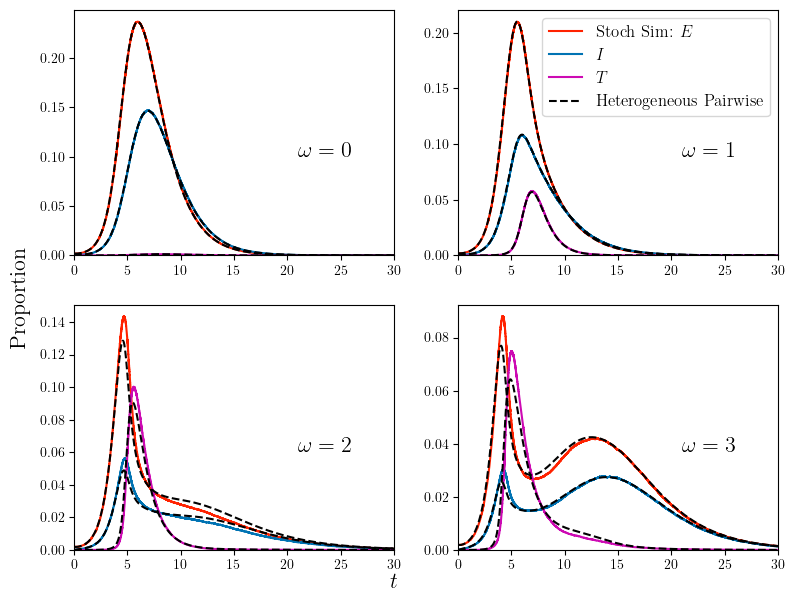

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict
import itertools
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

rng = np.random.default_rng(seed = 1)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

sigma = 0.7
gamma = 1
tau = 1.5
zeta = gamma
xi = 0.01

N=1000000
initial_E_count = 2000

IC = defaultdict(lambda: 'S')
for node in range(initial_E_count):
    IC[node] = 'E'

return_statuses = ['S', 'E', 'I', 'R', 'T']

deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)

G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))

fig, axes = plt.subplots(2,2,figsize=(8,6))
axes=axes.flatten()
plt.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.08)

# plt.figure(0, figsize= (4,3))
# plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.16)
# plt.figure(1, figsize= (4,3))
# plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.16)

for omega, ax in zip((0,1,2,3), axes):
    print("omega = {}".format(omega))
    H_seirt = nx.DiGraph()
    H_seirt.add_weighted_edges_from([('E', 'I', sigma), ('I', 'R', gamma), ('I', 'T', xi), ('T', 'R', zeta)], weight='rate')

    J_seirt = nx.DiGraph()
    J_seirt.add_weighted_edges_from([(('I', 'S'), ('I', 'E'), tau), (('T', 'I'), ('T', 'T'), omega), (('T', 'E'), ('T', 'T'), omega)], weight = 'rate')

    t, S, E, I, R, T = EoN.fast_simple_contagion(G, H_seirt, J_seirt, IC, return_statuses=return_statuses)  

    ax.plot(t, E/N, '-', color = colorI, label = 'Stoch Sim: $E$')
    ax.plot(t, I/N, '-', color = colorI2, label = '$I$')
    ax.plot(t, T/N, '-', color = colorR, label = '$T$')

    tt, SS, EE, II, RR, TT = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_seirt, J_seirt, IC, return_statuses,return_statuses=return_statuses, tmax = 40)
        
    ax.plot(tt, EE/N, 'k--', label = 'Heterogeneous Pairwise')
    ax.plot(tt, II/N, 'k--')
    ax.plot(tt, TT/N, 'k--')
    ax.set_xlim(xmin=0, xmax=30)
    ax.set_ylim(ymin=0)
    ax.text(0.7, 0.4, '$\\omega = {}$'.format(omega), transform=ax.transAxes, fontsize=16)
axes[1].legend(fontsize=12)
fig.supxlabel('$t$', fontsize=16)
fig.supylabel('Proportion', fontsize=16)
plt.savefig('contact_tracing_vs_HPW_rebound.png', dpi=900)
print('xi = {}'.format(xi) )
print('gamma = {}'.format(gamma) )
print('tau = {}'.format(tau) )
print('sigma = {}'.format(sigma) )
print('zeta = {}'.format(zeta)  )

KeyboardInterrupt: 

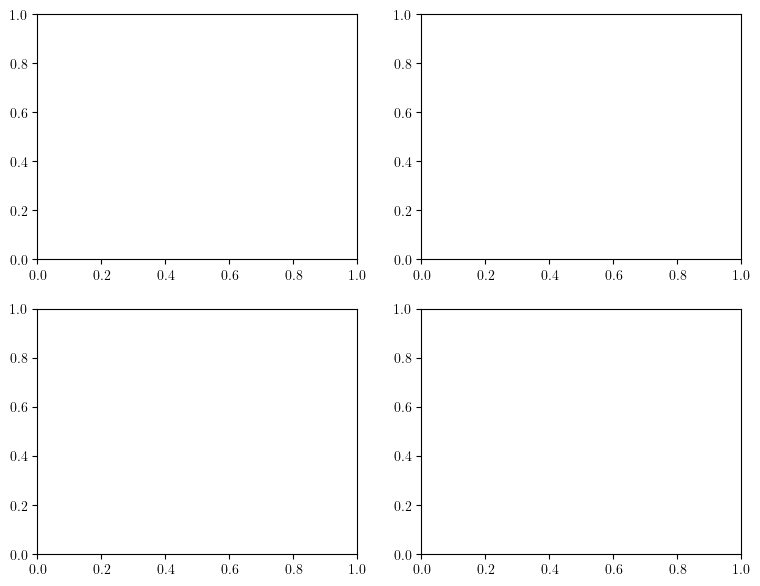

: 

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict
import itertools
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

rng = np.random.default_rng(seed = 1)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

sigma = 0.7
gamma = 1
tau = 1.5
zeta = gamma
xi = 0.01

N=500000
initial_E_count = 1000

IC = defaultdict(lambda: 'S')
for node in range(initial_E_count):
    IC[node] = 'E'

return_statuses = ['S', 'E', 'I', 'R', 'T']

deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)

G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))

fig, axes = plt.subplots(2,2,figsize=(8,6))
axes=axes.flatten()
plt.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.08)

# plt.figure(0, figsize= (4,3))
# plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.16)
# plt.figure(1, figsize= (4,3))
# plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.16)

for omega, ax in zip((0,1,2,3), axes):

    H_seirt = nx.DiGraph()
    H_seirt.add_weighted_edges_from([('E', 'I', sigma), ('I', 'R', gamma), ('I', 'T', xi), ('T', 'R', zeta)], weight='rate')

    J_seirt = nx.DiGraph()
    J_seirt.add_weighted_edges_from([(('I', 'S'), ('I', 'E'), tau), (('T', 'I'), ('T', 'T'), omega), (('T', 'E'), ('T', 'T'), omega)], weight = 'rate')

    t, S, E, I, R, T = EoN.Gillespie_simple_contagion(G, H_seirt, J_seirt, IC, return_statuses=return_statuses)  

    ax.plot(t, E/N, color = colorI, label = 'Stoch Sim: $E$')
    ax.plot(t, I/N, color = colorI2, label = '$I$')
    ax.plot(t, T/N, color = colorR, label = '$T$')

    tt, SS, EE, II, RR, TT = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_seirt, J_seirt, IC, return_statuses,return_statuses=return_statuses, tmax = 40)
        
    ax.plot(tt, EE/N, 'k--', label = 'Heterogeneous Pairwise')
    ax.plot(tt, II/N, 'k--')
    ax.plot(tt, TT/N, 'k--')
    ax.set_xlim(xmin=0, xmax=30)
    ax.set_ylim(ymin=0)
    ax.text(0.7, 0.4, '$\\omega = {}$'.format(omega), transform=ax.transAxes, fontsize=16)
axes[0].legend(fontsize=12)
fig.supxlabel('$t$', fontsize=16)
fig.supylabel('Proportion', fontsize=16)
plt.savefig('fig7_rebound.png', dpi=900)


In [ ]:
omega = 2.25
xi = 0.01
H_seirt = nx.DiGraph()
H_seirt.add_weighted_edges_from([('E', 'I', sigma), ('I', 'R', gamma), ('I', 'T', xi), ('T', 'R', zeta)], weight='rate')

J_seirt = nx.DiGraph()
J_seirt.add_weighted_edges_from([(('I', 'S'), ('I', 'E'), tau), (('T', 'I'), ('T', 'T'), omega), (('T', 'E'), ('T', 'T'), omega)], weight = 'rate')

tt, SS, EE, II, RR, TT = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_seirt, J_seirt, IC, return_statuses,return_statuses=return_statuses, tmax = 40)
        
plt.plot(tt, II, label = '$I$')
plt.plot(tt, TT, label = '$T$')

t, S, E, I, R, T = EoN.Gillespie_simple_contagion(G, H_seirt, J_seirt, IC, return_statuses=return_statuses)  

plt.plot(t, I)
plt.plot(t, T)